<a href="https://colab.research.google.com/github/malikshahzaib263/neurofive-ml-track/blob/main/Week_3_Task_2_Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 3 – Machine Learning Fundamentals

# Customer Churn Prediction — Working with a Business Problem

### Neurofive Solutions – Machine Learning Track

**Author:** Shahzaib Arshad

---

## Project Overview

Customer churn occurs when customers stop using a company's services. Predicting churn allows businesses to identify customers who may leave and take preventive action.

In this project, I will analyze the Telco Customer Churn dataset, train Logistic Regression and Decision Tree models, compare their performance, identify the most important churn factors, and present the findings from a business perspective.

## Project Objectives

The objectives of this project are:

- Perform quick Exploratory Data Analysis.
- Understand the relationship between customer characteristics and churn.
- Clean and prepare the dataset.
- Handle categorical variables using One-Hot Encoding.
- Identify and address class imbalance.
- Train Logistic Regression and Decision Tree models.
- Compare both models using multiple evaluation metrics.
- Identify the top three features driving customer churn.
- Present the results in business-friendly language.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully.")

Libraries imported successfully.


## Upload the Dataset

The Telco Customer Churn dataset is uploaded from the local computer into Google Colab.

In [2]:
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [3]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Initial Dataset Inspection

The dataset is inspected to understand its dimensions, columns, data types, and initial values.

In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 7043
Number of columns: 21


In [5]:
print("Dataset columns:\n")

for column in df.columns:
    print(column)

Dataset columns:

customerID
gender
SeniorCitizen
Partner
Dependents
tenure
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
MonthlyCharges
TotalCharges
Churn


In [6]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [10]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## Quick Exploratory Data Analysis

The target variable is `Churn`.

- `No` means the customer stayed.
- `Yes` means the customer left the company.

The distribution is checked to identify possible class imbalance.

In [11]:
print("Churn counts:\n")
print(df["Churn"].value_counts())

print("\nChurn percentages:\n")
print((df["Churn"].value_counts(normalize=True) * 100).round(2))

Churn counts:

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentages:

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


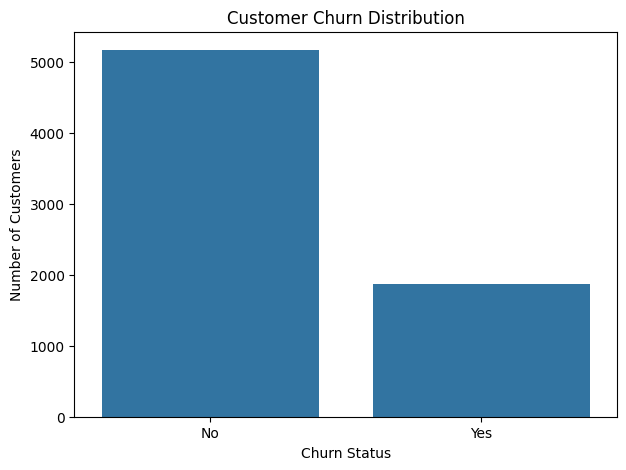

In [12]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.show()

## Contract Type and Churn

This visualization examines whether customers with different contract types have different churn behaviour.

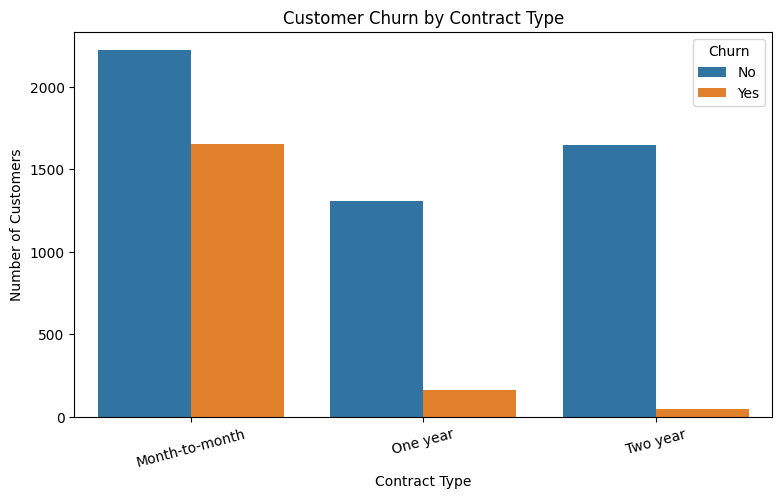

In [13]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.show()

## Customer Tenure and Churn

Tenure represents the number of months a customer has stayed with the company. This visualization examines whether newer customers are more likely to leave.

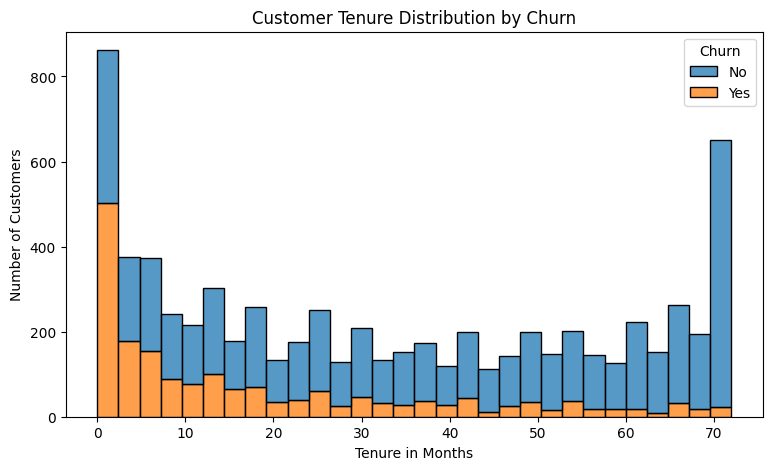

In [14]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    multiple="stack"
)

plt.title("Customer Tenure Distribution by Churn")
plt.xlabel("Tenure in Months")
plt.ylabel("Number of Customers")
plt.show()

## Monthly Charges and Churn

This boxplot compares the monthly charges paid by customers who stayed and customers who churned.

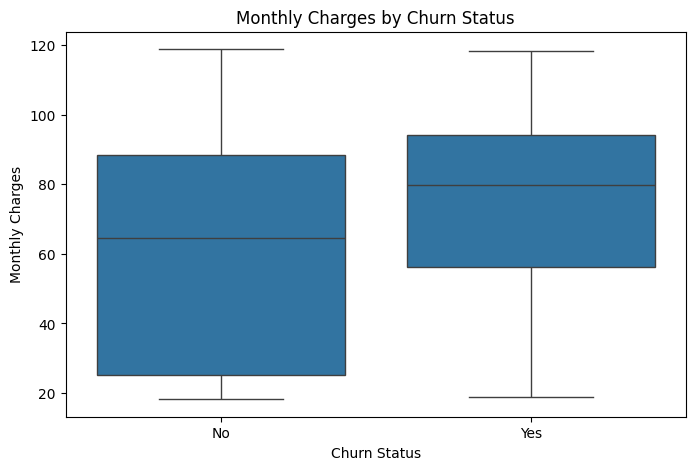

In [15]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges")
plt.show()

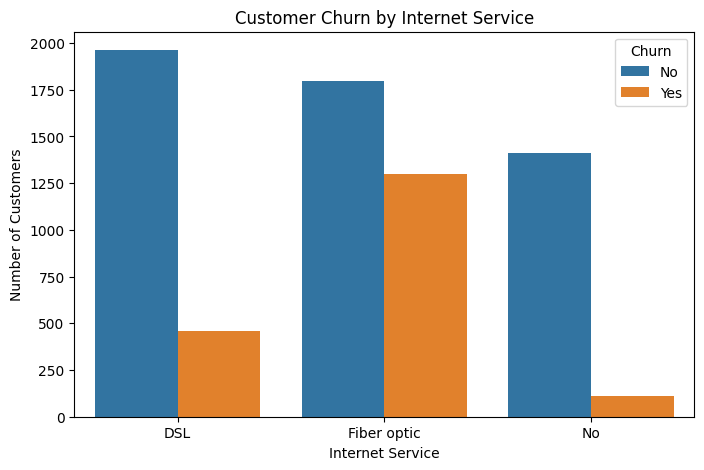

In [16]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.show()

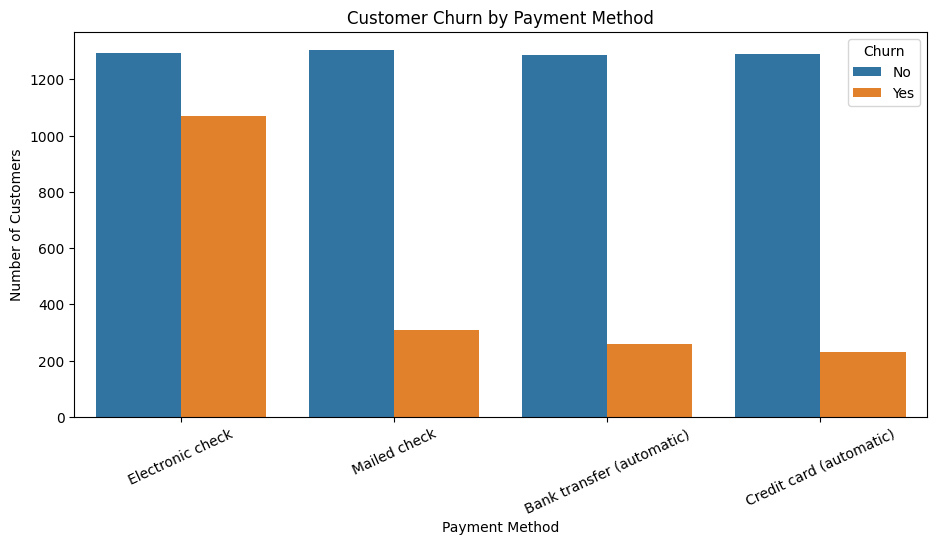

In [17]:
plt.figure(figsize=(11, 5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=25)
plt.show()

## Data Cleaning

The `TotalCharges` column is stored as an object because some rows contain blank spaces. It will be converted into a numerical column.

The `customerID` column will be removed because it is only an identifier and does not provide useful predictive information.

In [18]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("TotalCharges data type:", df["TotalCharges"].dtype)

TotalCharges data type: float64


In [19]:
df.isnull().sum().sort_values(ascending=False).head(10)

,0
TotalCharges,11
gender,0
SeniorCitizen,0
Partner,0
customerID,0
Dependents,0
tenure,0
MultipleLines,0
PhoneService,0
OnlineSecurity,0


In [20]:
total_charges_median = df["TotalCharges"].median()

df["TotalCharges"] = df["TotalCharges"].fillna(
    total_charges_median
)

print("Missing TotalCharges values:",
      df["TotalCharges"].isnull().sum())

Missing TotalCharges values: 0


In [21]:
df = df.drop(columns=["customerID"])

print("customerID removed successfully.")

customerID removed successfully.


## Target Variable Encoding

The target variable is converted into numerical form:

- `No` = 0
- `Yes` = 1

In [22]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

df["Churn"].value_counts()

,count
Churn,
0,5174
1,1869


In [23]:
class_counts = df["Churn"].value_counts()
class_percentages = (
    df["Churn"].value_counts(normalize=True) * 100
).round(2)

print("Class counts:")
print(class_counts)

print("\nClass percentages:")
print(class_percentages)

Class counts:
Churn
0    5174
1    1869
Name: count, dtype: int64

Class percentages:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


## Class Imbalance Observation

The dataset contains more customers who stayed than customers who churned, which means the target variable is moderately imbalanced. A model trained without considering this imbalance may focus more heavily on predicting the majority class. Therefore, accuracy alone may not provide a complete picture of model quality. Balanced class weights and metrics such as Precision, Recall, and F1-score are used to evaluate the models more fairly.

## Feature and Target Selection

The `Churn` column is the target variable. All remaining columns are used as input features.

In [24]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Feature data shape:", X.shape)
print("Target data shape:", y.shape)

Feature data shape: (7043, 19)
Target data shape: (7043,)


In [25]:
numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## Train-Test Split

The dataset is divided into:

- 80% training data
- 20% testing data

The `stratify` option maintains approximately the same churn distribution in both sets.

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("\nTraining churn distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting churn distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training features: (5634, 19)
Testing features: (1409, 19)

Training churn distribution:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64

Testing churn distribution:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


## Data Preprocessing

Numerical features are standardized using `StandardScaler`.

Categorical variables are converted into numerical form using `OneHotEncoder`. The `handle_unknown` option prevents errors if the testing data contains an unseen category.

In [27]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            numerical_columns
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_columns
        )
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


## Logistic Regression Model

Logistic Regression is a binary classification model. It estimates whether each customer is more likely to stay or churn.

Balanced class weights are used to give greater consideration to the smaller churn class.

In [28]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

logistic_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('categorical',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42))])

In [29]:
logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [30]:
logistic_predictions = logistic_model.predict(X_test)

print("First 10 predictions:")
print(logistic_predictions[:10])

First 10 predictions:
[0 1 0 1 0 1 1 0 0 1]


In [31]:
logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

logistic_precision = precision_score(
    y_test,
    logistic_predictions
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions
)

logistic_f1 = f1_score(
    y_test,
    logistic_predictions
)

print(f"Accuracy:  {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall:    {logistic_recall:.4f}")
print(f"F1-score:  {logistic_f1:.4f}")

Accuracy:  0.7381
Precision: 0.5043
Recall:    0.7834
F1-score:  0.6136


In [33]:
print("Logistic Regression Classification Report:\n")

print(
    classification_report(
        y_test,
        logistic_predictions,
        target_names=["Stayed", "Churned"]
    )
)

Logistic Regression Classification Report:

              precision    recall  f1-score   support

      Stayed       0.90      0.72      0.80      1035
     Churned       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



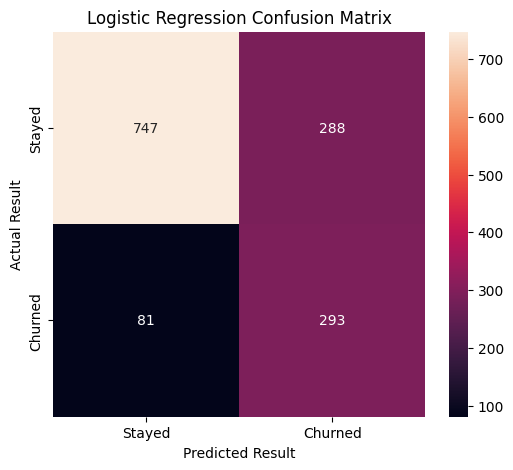

In [34]:
logistic_cm = confusion_matrix(
    y_test,
    logistic_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    logistic_cm,
    annot=True,
    fmt="d",
    xticklabels=["Stayed", "Churned"],
    yticklabels=["Stayed", "Churned"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Result")
plt.ylabel("Actual Result")
plt.show()

## Decision Tree Classifier

A Decision Tree creates understandable decision rules using customer characteristics. It is particularly useful in business problems because its predictions and feature importance values are easier to explain to non-technical stakeholders.

In [35]:
tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=5,
                min_samples_split=10,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

tree_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('categorical',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                                        min_samples_split=10,
                                        random_state=42))])

In [36]:
tree_model.fit(X_train, y_train)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [37]:
tree_predictions = tree_model.predict(X_test)

print("First 10 predictions:")
print(tree_predictions[:10])

First 10 predictions:
[0 1 0 1 0 1 1 0 0 0]


In [38]:
tree_accuracy = accuracy_score(
    y_test,
    tree_predictions
)

tree_precision = precision_score(
    y_test,
    tree_predictions
)

tree_recall = recall_score(
    y_test,
    tree_predictions
)

tree_f1 = f1_score(
    y_test,
    tree_predictions
)

print(f"Accuracy:  {tree_accuracy:.4f}")
print(f"Precision: {tree_precision:.4f}")
print(f"Recall:    {tree_recall:.4f}")
print(f"F1-score:  {tree_f1:.4f}")

Accuracy:  0.7346
Precision: 0.5000
Recall:    0.8075
F1-score:  0.6176


In [39]:
print("Decision Tree Classification Report:\n")

print(
    classification_report(
        y_test,
        tree_predictions,
        target_names=["Stayed", "Churned"]
    )
)

Decision Tree Classification Report:

              precision    recall  f1-score   support

      Stayed       0.91      0.71      0.80      1035
     Churned       0.50      0.81      0.62       374

    accuracy                           0.73      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.73      0.75      1409



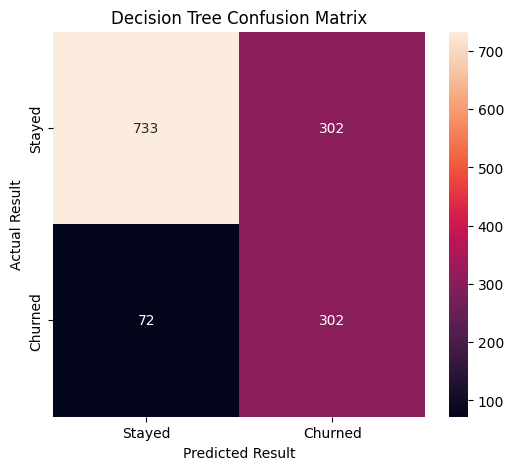

In [40]:
tree_cm = confusion_matrix(
    y_test,
    tree_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    tree_cm,
    annot=True,
    fmt="d",
    xticklabels=["Stayed", "Churned"],
    yticklabels=["Stayed", "Churned"]
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Result")
plt.ylabel("Actual Result")
plt.show()

## Model Comparison

The two models are compared using Accuracy, Precision, Recall, and F1-score.

Because identifying customers likely to leave is important, Recall and F1-score are particularly useful metrics for this business problem.

In [41]:
model_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Logistic Regression": [
        logistic_accuracy,
        logistic_precision,
        logistic_recall,
        logistic_f1
    ],
    "Decision Tree": [
        tree_accuracy,
        tree_precision,
        tree_recall,
        tree_f1
    ]
})

model_comparison[
    ["Logistic Regression", "Decision Tree"]
] = model_comparison[
    ["Logistic Regression", "Decision Tree"]
].round(4)

model_comparison

,Metric,Logistic Regression,Decision Tree
0,Accuracy,0.7381,0.7346
1,Precision,0.5043,0.5000
2,Recall,0.7834,0.8075
3,F1-score,0.6136,0.6176


In [42]:
if logistic_f1 > tree_f1:
    better_model = "Logistic Regression"
elif tree_f1 > logistic_f1:
    better_model = "Decision Tree"
else:
    better_model = "Both models performed equally"

print("Better model based on F1-score:", better_model)

Better model based on F1-score: Decision Tree


## Decision Tree Feature Importance

The Decision Tree provides an importance score for each transformed feature. Higher scores indicate that a feature contributed more strongly to the model's churn predictions.

In [43]:
trained_preprocessor = tree_model.named_steps["preprocessor"]

encoded_categorical_names = (
    trained_preprocessor
    .named_transformers_["categorical"]
    .get_feature_names_out(categorical_columns)
)

all_feature_names = np.concatenate([
    numerical_columns,
    encoded_categorical_names
])

print("Total transformed features:", len(all_feature_names))

Total transformed features: 30


In [44]:
trained_tree = tree_model.named_steps["classifier"]

feature_importances = trained_tree.feature_importances_

print("Number of importance values:", len(feature_importances))

Number of importance values: 30


In [45]:
importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": feature_importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

importance_df.head(10)

,Feature,Importance
0,Contract_Two year,0.405269
1,Contract_One year,0.253452
2,InternetService_Fiber optic,0.111558
3,tenure,0.094694
4,StreamingMovies_Yes,0.034102
5,TotalCharges,0.027222
6,PaymentMethod_Electronic check,0.020621
7,MonthlyCharges,0.019440
8,InternetService_No,0.015233
9,PhoneService_Yes,0.012017


In [46]:
top_3_features = importance_df.head(3)

print("Top 3 Features Driving Customer Churn:\n")
print(top_3_features)

Top 3 Features Driving Customer Churn:

                       Feature  Importance
0            Contract_Two year    0.405269
1            Contract_One year    0.253452
2  InternetService_Fiber optic    0.111558


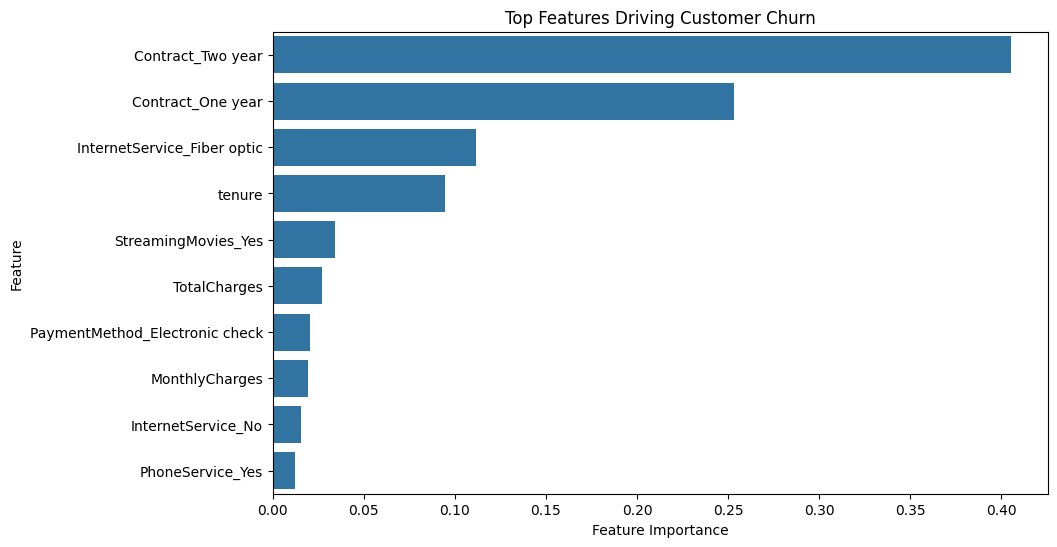

In [47]:
top_10_features = importance_df.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_10_features,
    x="Importance",
    y="Feature"
)

plt.title("Top Features Driving Customer Churn")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.show()

In [48]:
print("FINAL PROJECT RESULTS")
print("-" * 40)

print("\nBetter Model:")
print(better_model)

print("\nTop 3 Churn Features:")

for index, row in top_3_features.iterrows():
    print(
        f"{index + 1}. {row['Feature']} "
        f"({row['Importance']:.4f})"
    )

FINAL PROJECT RESULTS
----------------------------------------

Better Model:
Decision Tree

Top 3 Churn Features:
1. Contract_Two year (0.4053)
2. Contract_One year (0.2535)
3. InternetService_Fiber optic (0.1116)


## Business Summary

The analysis shows that **[Feature 1]**, **[Feature 2]**, and **[Feature 3]** are the strongest factors influencing customer churn. Customers showing these characteristics should be considered higher-risk and may benefit from early retention support. Based on the F1-score, **[better model name]** provided the stronger overall balance between identifying churners and avoiding incorrect predictions. The company should consider targeted discounts, contract incentives, and proactive customer service for customers with a high predicted churn risk. These actions could help improve customer loyalty and reduce the cost of replacing lost customers.

## Conclusion

In this project, I performed exploratory data analysis on the Telco Customer Churn dataset and examined the relationship between contract type, tenure, monthly charges, and churn. I cleaned the data, encoded categorical variables, and addressed class imbalance using balanced class weights. Logistic Regression and Decision Tree models were trained and compared using Accuracy, Precision, Recall, and F1-score. Finally, Decision Tree feature importance was used to identify the top three factors driving customer churn. This project demonstrates how machine learning can support customer retention and practical business decision-making.